<a href="https://colab.research.google.com/github/VintaBytes/Ciencia-de-datos/blob/main/libros/ciencia-de-datos-con-python/volumen-05/cuadernos/CienciaDeDatos_Tomo5_Cuaderno04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Capítulo 4 · Funciones de activación

En el cuaderno anterior seguimos la información a través de varias capas. En este recorrido observaremos qué cambia cuando, después de cada suma ponderada, aplicamos una función de activación.

Trabajaremos con ReLU, sigmoid, tanh y softmax. Las implementaremos con NumPy, representaremos sus transformaciones y relacionaremos cada una con el lugar que suele ocupar dentro de una red. Todavía no entrenaremos modelos: los pesos, las pérdidas y su actualización corresponden a los próximos capítulos.


## Objetivos del cuaderno

Al finalizar este recorrido, deberías poder:

- comprobar numéricamente que varias transformaciones lineales pueden reducirse a una sola;
- reconocer cómo una activación introduce no linealidad;
- implementar ReLU, sigmoid, tanh y softmax con NumPy;
- interpretar el rango y el comportamiento de cada función;
- distinguir probabilidades binarias, multiclase y multietiqueta;
- elegir una activación de salida inicial según el tipo de problema.


## Importación de librerías

Usaremos NumPy para realizar los cálculos, Pandas para organizar resultados y Matplotlib para representar las funciones. No necesitamos descargar un dataset ni importar una biblioteca de Deep Learning, porque el objetivo es observar directamente cada transformación.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Varias capas lineales siguen siendo una transformación lineal

Una capa densa sin activación calcula una transformación de la forma:

$$
\mathbf{z}=\mathbf{W}\mathbf{x}+\mathbf{b}
$$

Si encadenamos dos capas de este tipo, sus matrices y bias pueden combinarse en una sola matriz y un único vector equivalentes. Comprobaremos esa propiedad con una entrada de dos valores, una primera capa de tres neuronas y una salida de una neurona.


In [2]:
entrada = np.array([1.2, -0.7])

pesos_1 = np.array([
    [0.5, -0.4],
    [1.0,  0.3],
    [-0.6, 0.8],
])
bias_1 = np.array([0.2, -0.1, 0.4])

pesos_2 = np.array([[0.7, -0.5, 0.9]])
bias_2 = np.array([0.3])

salida_dos_capas = pesos_2 @ (pesos_1 @ entrada + bias_1) + bias_2

pesos_equivalentes = pesos_2 @ pesos_1
bias_equivalente = pesos_2 @ bias_1 + bias_2
salida_una_capa = pesos_equivalentes @ entrada + bias_equivalente

print("Salida de las dos capas:", np.round(salida_dos_capas, 4))
print("Salida de la capa equivalente:", np.round(salida_una_capa, 4))
print("¿Los resultados coinciden?", np.allclose(salida_dos_capas, salida_una_capa))


Salida de las dos capas: [-0.181]
Salida de la capa equivalente: [-0.181]
¿Los resultados coinciden? True


Los dos recorridos producen **−0,181**. La igualdad no es una coincidencia de esta entrada: las matrices y los bias equivalentes describen la misma transformación para cualquier valor compatible.

Por eso, agregar capas lineales sin activaciones no permite representar relaciones cualitativamente nuevas. La red puede tener más operaciones y más conexiones, pero toda la cadena continúa siendo reducible a una única transformación lineal.


Introduzcamos ahora ReLU entre dos transformaciones sencillas. Sin ReLU, la composición vuelve a ser una recta. Con ReLU, los valores negativos de la primera transformación se convierten en cero y aparece un cambio de comportamiento que una única recta no puede reproducir en todo el dominio.


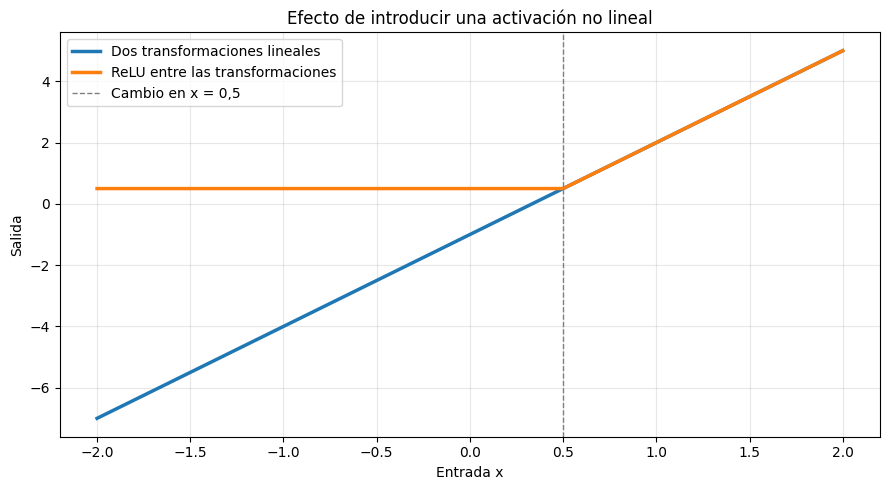

In [3]:
x = np.linspace(-2, 2, 300)

primera_transformacion = 2 * x - 1
salida_sin_activacion = 1.5 * primera_transformacion + 0.5
salida_con_relu = 1.5 * np.maximum(0, primera_transformacion) + 0.5

plt.figure(figsize=(9, 5))
plt.plot(x, salida_sin_activacion, label="Dos transformaciones lineales", linewidth=2.5)
plt.plot(x, salida_con_relu, label="ReLU entre las transformaciones", linewidth=2.5)
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Cambio en x = 0,5")
plt.title("Efecto de introducir una activación no lineal")
plt.xlabel("Entrada x")
plt.ylabel("Salida")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


La curva sin activación es una única recta. Cuando intercalamos ReLU, la salida permanece en **0,5** hasta que la primera transformación se vuelve positiva; a partir de allí comienza a crecer. Aunque cada tramo sea recto, el comportamiento completo es no lineal.

Este ejemplo no representa una red entrenada. Solo permite aislar la función que cumple la activación entre dos capas.


## 2. Implementar las activaciones

Definiremos las cuatro funciones del capítulo. ReLU, sigmoid y tanh pueden aplicarse elemento por elemento. Softmax es diferente: recibe un conjunto de puntuaciones y las transforma conjuntamente para que el resultado sume 1.

En la implementación de softmax restaremos el valor máximo antes de calcular las exponenciales. Esta operación no cambia las probabilidades finales y evita trabajar con números innecesariamente grandes.


In [4]:
def relu(z):
    return np.maximum(0, z)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def tanh(z):
    return np.tanh(z)


def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    logits_estables = logits - np.max(logits)
    exponenciales = np.exp(logits_estables)
    return exponenciales / exponenciales.sum()


valores = np.array([-5, -2, -1, 0, 1, 2, 5], dtype=float)

comparacion_activaciones = pd.DataFrame({
    "z": valores,
    "ReLU": relu(valores),
    "sigmoid": sigmoid(valores),
    "tanh": tanh(valores),
})

comparacion_activaciones.round(4)


,z,ReLU,sigmoid,tanh
0,-5.0,0.0,0.0067,-0.9999
1,-2.0,0.0,0.1192,-0.9640
2,-1.0,0.0,0.2689,-0.7616
3,0.0,0.0,0.5000,0.0000
4,1.0,1.0,0.7311,0.7616
5,2.0,2.0,0.8808,0.9640
6,5.0,5.0,0.9933,0.9999


La tabla permite observar tres rangos distintos:

- ReLU reemplaza los valores negativos por cero y conserva los positivos;
- sigmoid comprime todos los valores entre 0 y 1, y devuelve 0,5 cuando $z=0$;
- tanh produce valores entre −1 y 1, atraviesa el origen y conserva el signo.

Softmax no aparece en esta comparación elemento por elemento porque su resultado para un valor depende también de los demás logits del conjunto.


Representaremos ahora las tres curvas sobre el mismo intervalo. Separarlas en paneles permite respetar sus diferentes escalas sin ocultar su forma.


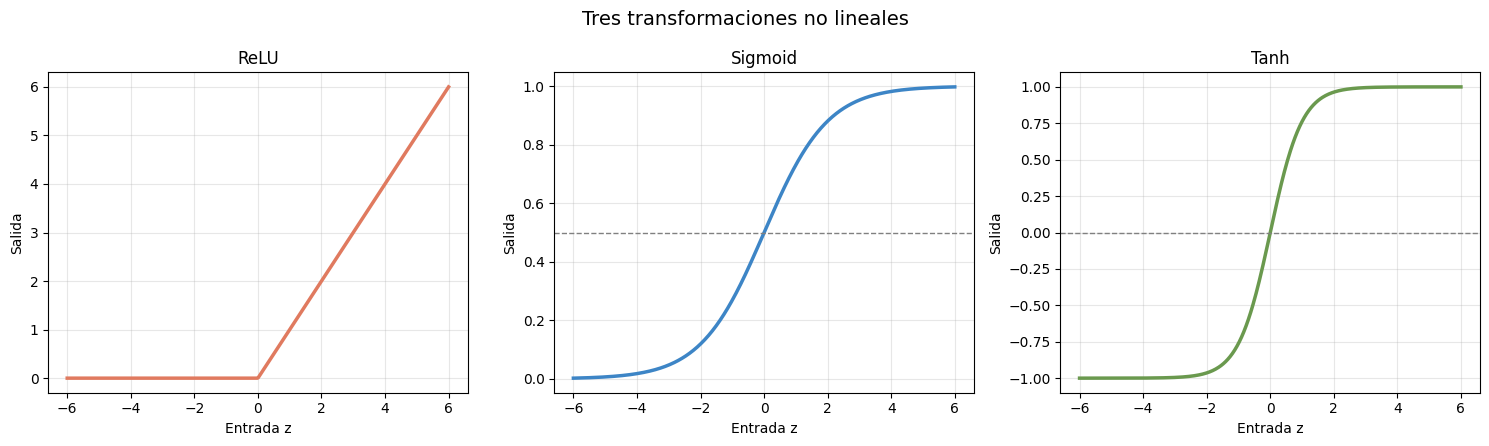

In [5]:
z = np.linspace(-6, 6, 500)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))

ejes[0].plot(z, relu(z), color="#E07A5F", linewidth=2.5)
ejes[0].set_title("ReLU")
ejes[0].set_xlabel("Entrada z")
ejes[0].set_ylabel("Salida")

ejes[1].plot(z, sigmoid(z), color="#3D85C6", linewidth=2.5)
ejes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
ejes[1].set_title("Sigmoid")
ejes[1].set_xlabel("Entrada z")
ejes[1].set_ylabel("Salida")

ejes[2].plot(z, tanh(z), color="#6A994E", linewidth=2.5)
ejes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
ejes[2].set_title("Tanh")
ejes[2].set_xlabel("Entrada z")
ejes[2].set_ylabel("Salida")

for eje in ejes:
    eje.grid(alpha=0.3)

fig.suptitle("Tres transformaciones no lineales", fontsize=14)
plt.tight_layout()
plt.show()


ReLU tiene un tramo horizontal para entradas negativas y luego crece sin una cota superior. Sigmoid y tanh, en cambio, se aplanan en los extremos: sus salidas se acercan cada vez más a los límites de sus respectivos rangos.

Ese aplanamiento se denomina **saturación**. Su influencia sobre el aprendizaje se comprenderá mejor cuando estudiemos gradientes y backpropagation; aquí alcanza con reconocerlo en la forma de las curvas.


## 3. ReLU en una representación intermedia

En las capas ocultas no necesitamos que cada valor sea una probabilidad. Buscamos una transformación que permita construir representaciones no lineales útiles para la capa siguiente.

Aplicaremos ReLU a la salida previa a la activación de seis neuronas.


In [6]:
z_capa_oculta = np.array([-3.2, 1.4, -0.6, 0.0, 2.7, -1.1])
salida_relu = relu(z_capa_oculta)

detalle_relu = pd.DataFrame({
    "neurona": np.arange(1, len(z_capa_oculta) + 1),
    "antes_de_relu": z_capa_oculta,
    "despues_de_relu": salida_relu,
})

display(detalle_relu)
print("Valores convertidos en cero:", np.count_nonzero(salida_relu == 0))


,neurona,antes_de_relu,despues_de_relu
0,1,-3.2,0.0
1,2,1.4,1.4
2,3,-0.6,0.0
3,4,0.0,0.0
4,5,2.7,2.7
5,6,-1.1,0.0


Valores convertidos en cero: 4


Cuatro de las seis salidas quedan en cero: las tres que eran negativas y la que ya valía cero. Las dos activaciones positivas continúan sin cambios hacia la capa siguiente.

Que una activación sea cero para este ejemplo no significa por sí solo que exista una “neurona muerta”. Ese problema aparece cuando una neurona queda sistemáticamente en la región negativa durante el entrenamiento; aquí solo estamos observando una propagación hacia adelante con valores fijos.


## 4. Sigmoid: probabilidad estimada y decisión binaria

Sigmoid transforma una puntuación sin acotar en un valor entre 0 y 1. En una salida binaria, ese valor puede interpretarse como la probabilidad estimada de la clase codificada como 1.

La probabilidad y la decisión final son pasos distintos. Usaremos un umbral de 0,5 para hacer visible esa separación.


In [7]:
logits_binarios = np.array([-3.2, -0.4, 0.0, 1.7, 4.0])
probabilidades_binarias = sigmoid(logits_binarios)
umbral = 0.5
clases_predichas = (probabilidades_binarias >= umbral).astype(int)

resultado_binario = pd.DataFrame({
    "logit": logits_binarios,
    "probabilidad_clase_1": probabilidades_binarias,
    "clase_con_umbral_0_5": clases_predichas,
})

resultado_binario.round(4)


,logit,probabilidad_clase_1,clase_con_umbral_0_5
0,-3.2,0.0392,0
1,-0.4,0.4013,0
2,0.0,0.5000,1
3,1.7,0.8455,1
4,4.0,0.9820,1


El logit **−3,2** se transforma en una probabilidad aproximada de **0,039**, mientras que **1,7** se convierte en **0,846**. El caso con logit cero produce exactamente **0,5** y queda asignado a la clase 1 por la regla utilizada.

Sigmoid no elige el umbral ni garantiza que 0,5 sea la mejor decisión para cualquier problema. El umbral debe analizarse según el costo de los distintos errores, como ya vimos al estudiar clasificación.


## 5. Tanh: una salida centrada en cero

Tanh comparte con sigmoid su forma de S y la saturación en los extremos, pero su rango va de −1 a 1. Compararemos ambas funciones sobre entradas simétricas alrededor de cero.


In [8]:
entradas_simetricas = np.array([-2, -1, 0, 1, 2], dtype=float)

comparacion_sigmoid_tanh = pd.DataFrame({
    "z": entradas_simetricas,
    "sigmoid": sigmoid(entradas_simetricas),
    "tanh": tanh(entradas_simetricas),
})

display(comparacion_sigmoid_tanh.round(4))
print("Promedio de las salidas sigmoid:", round(sigmoid(entradas_simetricas).mean(), 4))
print("Promedio de las salidas tanh:", round(tanh(entradas_simetricas).mean(), 4))


,z,sigmoid,tanh
0,-2.0,0.1192,-0.9640
1,-1.0,0.2689,-0.7616
2,0.0,0.5000,0.0000
3,1.0,0.7311,0.7616
4,2.0,0.8808,0.9640


Promedio de las salidas sigmoid: 0.5
Promedio de las salidas tanh: 0.0


Para estas entradas simétricas, las salidas de sigmoid se distribuyen alrededor de **0,5**, mientras que las de tanh se distribuyen alrededor de **0**. Además, tanh conserva valores negativos para entradas negativas.

Esta característica explica qué significa afirmar que tanh está centrada en cero. No demuestra que sea mejor que ReLU o sigmoid en cualquier red: su conveniencia depende de la arquitectura y del papel que deba cumplir.


## 6. Softmax: varias clases que compiten entre sí

Supongamos que la salida de una red contiene tres logits asociados con las clases `gato`, `perro` y `caballo`. Softmax transformará esas puntuaciones en una distribución de probabilidades cuya suma sea 1.


,clase,logit,probabilidad_softmax
0,gato,2.1,0.7382
1,perro,0.8,0.2012
2,caballo,-0.4,0.0606


Suma de probabilidades: 1.0
Clase predicha: gato


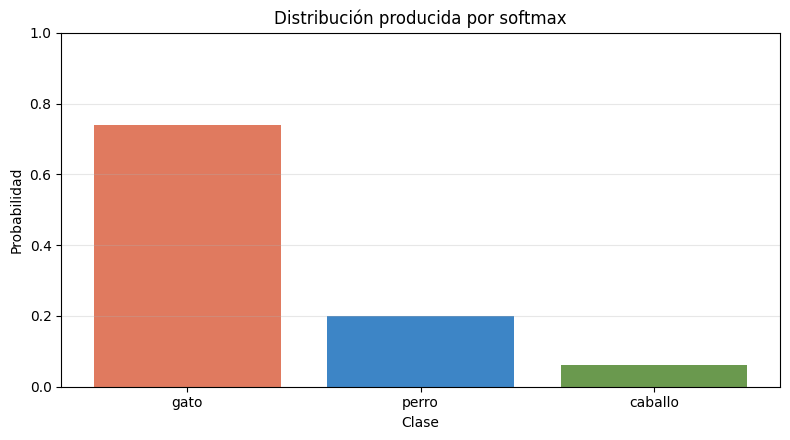

In [9]:
clases = np.array(["gato", "perro", "caballo"])
logits_multiclase = np.array([2.1, 0.8, -0.4])
probabilidades_multiclase = softmax(logits_multiclase)
indice_predicho = np.argmax(probabilidades_multiclase)

resultado_multiclase = pd.DataFrame({
    "clase": clases,
    "logit": logits_multiclase,
    "probabilidad_softmax": probabilidades_multiclase,
})

display(resultado_multiclase.round(4))
print("Suma de probabilidades:", round(probabilidades_multiclase.sum(), 4))
print("Clase predicha:", clases[indice_predicho])

plt.figure(figsize=(8, 4.5))
plt.bar(clases, probabilidades_multiclase, color=["#E07A5F", "#3D85C6", "#6A994E"])
plt.title("Distribución producida por softmax")
plt.xlabel("Clase")
plt.ylabel("Probabilidad")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Las probabilidades suman **1** y la clase `gato` recibe el valor mayor, aproximadamente **0,738**. `np.argmax()` selecciona la posición de esa probabilidad y permite recuperar la etiqueta correspondiente.

Softmax conserva el orden de los logits, pero no convierte la predicción en una certeza. La distribución expresa cómo reparte el modelo sus puntuaciones entre las clases; un valor alto puede acompañar igualmente una predicción equivocada.


La resta del logit máximo permite calcular softmax de manera estable. Verifiquemos que sumar 1000 a todos los logits no modifica la distribución: lo que importa son sus diferencias relativas.


In [10]:
logits_moderados = np.array([2.0, 1.0, 0.0])
logits_grandes = np.array([1002.0, 1001.0, 1000.0])

probabilidades_moderadas = softmax(logits_moderados)
probabilidades_grandes = softmax(logits_grandes)

print("Con logits moderados:", np.round(probabilidades_moderadas, 6))
print("Con logits grandes:  ", np.round(probabilidades_grandes, 6))
print("¿Las distribuciones coinciden?", np.allclose(
    probabilidades_moderadas, probabilidades_grandes
))


Con logits moderados: [0.665241 0.244728 0.090031]
Con logits grandes:   [0.665241 0.244728 0.090031]
¿Las distribuciones coinciden? True


Ambos conjuntos producen aproximadamente `[0.665241, 0.244728, 0.090031]`. Restar el máximo transforma `[1002, 1001, 1000]` en `[0, −1, −2]` antes de calcular las exponenciales y evita números enormes sin alterar las probabilidades.

Las bibliotecas de Deep Learning realizan internamente este tipo de cuidado numérico. Implementarlo aquí nos permite comprender por qué una fórmula matemática puede necesitar una forma computacional más robusta.


## 7. Multiclase no es lo mismo que multietiqueta

Softmax es apropiada cuando las clases son mutuamente excluyentes: aumentar la probabilidad de una reduce necesariamente la parte disponible para las demás.

Si varias etiquetas pueden estar presentes al mismo tiempo, necesitamos probabilidades independientes. En ese caso puede aplicarse sigmoid a cada logit de salida.


In [11]:
logits_objetos = np.array([2.0, 1.0, -1.5, 1.6])
etiquetas = np.array(["persona", "automóvil", "bicicleta", "perro"])

salida_softmax = softmax(logits_objetos)
salida_sigmoid = sigmoid(logits_objetos)

comparacion_salidas = pd.DataFrame({
    "etiqueta": etiquetas,
    "softmax_multiclase": salida_softmax,
    "sigmoid_multietiqueta": salida_sigmoid,
})

display(comparacion_salidas.round(4))
print("Suma softmax:", round(salida_softmax.sum(), 4))
print("Suma de sigmoid independientes:", round(salida_sigmoid.sum(), 4))


,etiqueta,softmax_multiclase,sigmoid_multietiqueta
0,persona,0.4835,0.8808
1,automóvil,0.1779,0.7311
2,bicicleta,0.0146,0.1824
3,perro,0.3241,0.8320


Suma softmax: 1.0
Suma de sigmoid independientes: 2.6263


Softmax obliga a repartir una unidad completa entre las cuatro categorías. Las sigmoid independientes pueden asignar simultáneamente valores altos a `persona`, `automóvil` y `perro`; por eso su suma es aproximadamente **2,626** y no necesita valer 1.

La diferencia no es meramente técnica. Responde a la pregunta del problema: **¿debemos elegir una sola clase o pueden ser verdaderas varias etiquetas?**


## 8. Relacionar la salida con el tipo de problema

Las capas ocultas de una red densa suelen comenzar con ReLU. La capa final se diseña según el significado que debe tener la predicción.

| Tipo de problema | Neuronas de salida | Activación habitual | Interpretación |
|---|---:|---|---|
| Regresión con un objetivo | 1 | lineal | valor numérico sin acotar |
| Clasificación binaria | 1 | sigmoid | probabilidad estimada de la clase 1 |
| Multiclase con $K$ clases | $K$ | softmax | distribución entre clases excluyentes |
| Multietiqueta con $K$ etiquetas | $K$ | sigmoid | probabilidad independiente por etiqueta |

Una salida lineal también es una elección de activación. En Keras, `Dense(1)` utiliza por defecto una transformación equivalente a $f(z)=z$.


La misma parte oculta podría terminar de distintas maneras:

```python
# Regresión
Dense(1)

# Clasificación binaria
Dense(1, activation="sigmoid")

# Cinco clases mutuamente excluyentes
Dense(5, activation="softmax")

# Cinco etiquetas independientes
Dense(5, activation="sigmoid")
```

El número de neuronas y la activación final permiten leer qué forma tendrá la respuesta. Todavía no elegimos una función de pérdida: esa decisión debe ser compatible con la salida y será el tema del próximo capítulo.


## 9. Una pequeña exploración

Modificá los logits de la siguiente celda y observá cómo cambia la distribución. Probá acercar los dos valores mayores, separarlos o sumar la misma constante a los tres.


In [12]:
logits_a_explorar = np.array([1.5, 1.4, 0.0])
probabilidades_a_explorar = softmax(logits_a_explorar)

exploracion = pd.DataFrame({
    "clase": ["A", "B", "C"],
    "logit": logits_a_explorar,
    "probabilidad": probabilidades_a_explorar,
})

display(exploracion.round(4))
print("Clase con mayor probabilidad:", exploracion.loc[
    exploracion["probabilidad"].idxmax(), "clase"
])


,clase,logit,probabilidad
0,A,1.5,0.4699
1,B,1.4,0.4252
2,C,0.0,0.1049


Clase con mayor probabilidad: A


Con los valores iniciales, las clases A y B reciben probabilidades cercanas —aproximadamente **0,470** y **0,425**— porque sus logits solo difieren en 0,1. La clase A sigue siendo la predicha porque conserva el valor mayor.

Si sumás la misma constante a los tres logits, la distribución no cambiará. Si aumentás solamente uno, su probabilidad crecerá y las demás deberán disminuir porque el total continúa siendo 1.


## Cierre del cuaderno

Comprobamos que encadenar transformaciones lineales no basta para aprovechar la profundidad de una red y observamos cómo ReLU introduce un cambio de comportamiento entre capas.

Después implementamos y representamos ReLU, sigmoid y tanh, y construimos una versión numéricamente estable de softmax. Vimos que ReLU suele cumplir un papel interno, mientras que sigmoid y softmax dan significado probabilístico a diferentes tipos de salida. También distinguimos la competencia entre clases de una salida softmax de las probabilidades independientes de una salida multietiqueta.

Ya podemos interpretar qué forma tendrá la respuesta de una red. El próximo paso será medir qué tan alejada está esa respuesta del valor correcto mediante una función de pérdida.


## Para pensar

1. ¿Por qué veinte capas lineales consecutivas no reemplazan la necesidad de una activación no lineal?
2. ¿Qué diferencia conceptual existe entre aplicar softmax y aplicar varias sigmoid a una misma capa de salida?
3. Si una red debe predecir el precio de una vivienda, ¿por qué una salida sigmoid sería una elección poco conveniente sin una transformación adicional del objetivo?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
